# Evaluate the Prompt U-Net models against each other
### This evaluation run uses FLARE_2022 and HaNSeg

In [1]:
import os
import sys#

sys.path.append(os.path.join(os.getcwd(), '..', '..'))

from evaluation.eval_prompt_unet.eval_p_unet_pipeline import PromptUNetTester

dimensions = ['x', 'y', 'z'] 
offsets = [5, 12, 30]
models = [
    'p_unet_21.keras',
    'p_unet_292.keras',
    'p_unet_300.keras',
    'p_unet_301.keras',
]

max_data_points = 1500 # must be large enough, for datagen to capture more unique tasks and axis 
models_dir = "training/"

E0000 00:00:1776670871.552064    1768 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776670871.561172    1768 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776670871.584100    1768 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776670871.584119    1768 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776670871.584124    1768 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776670871.584127    1768 computation_placer.cc:177] computation placer already registered. Please check linka

### 1. Evaluate on HanSeg (MRI)

--- RUNNING HANSEG (MRI) EVALUATION ---
[INFO] CPU detected — forcing float32 compute policy for all models.

Loading NPZ dataset(s)…
Loaded 42 PIDs from /home/dpxuser/prompt-unet/data/test_data/han_seg_mri.npz

Final dataset size: 42 patients.


   EVALUATING OFFSET: 5 | AXIS: ['x', 'y', 'z']

Creating new Data Points ...
It took 27 seconds

--- [SECTION 1: METRICS] ---
Testing p_unet_21.keras... Done. Took 234.9 seconds.
[p_unet_21.keras] -> Avg Dice: 0.790
Testing p_unet_292.keras... Done. Took 312.2 seconds.
[p_unet_292.keras] -> Avg Dice: 0.777
Testing p_unet_300.keras... Done. Took 476.5 seconds.
[p_unet_300.keras] -> Avg Dice: 0.786
Testing p_unet_301.keras... Done. Took 478.8 seconds.
[p_unet_301.keras] -> Avg Dice: 0.776

   EVALUATING OFFSET: 12 | AXIS: ['x', 'y', 'z']

Creating new Data Points ...
It took 25 seconds

--- [SECTION 1: METRICS] ---
Testing p_unet_21.keras... Done. Took 229.8 seconds.
[p_unet_21.keras] -> Avg Dice: 0.703
Testing p_unet_292.keras... Done. Took 30

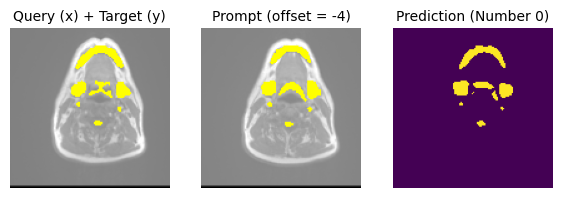

Dice: 0.812



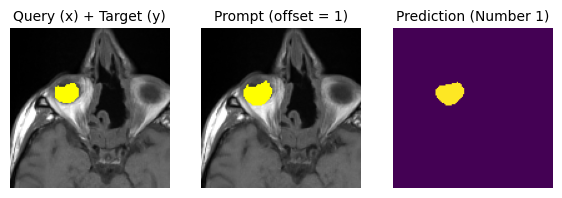

Dice: 0.873


>> Visualizing predictions for: p_unet_292.keras (Threshold: 0.5)


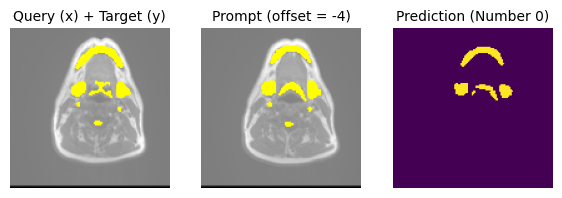

Dice: 0.760



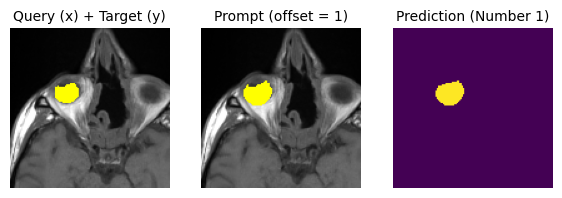

Dice: 0.826


>> Visualizing predictions for: p_unet_300.keras (Threshold: 0.5)


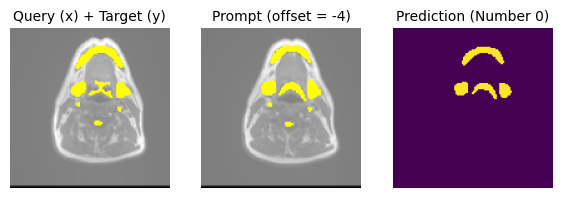

Dice: 0.772



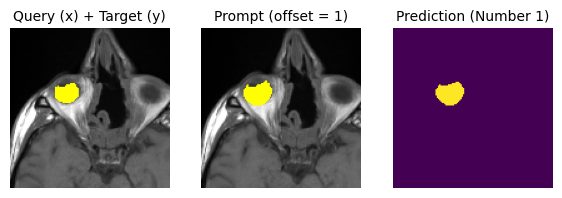

Dice: 0.859


>> Visualizing predictions for: p_unet_301.keras (Threshold: 0.5)


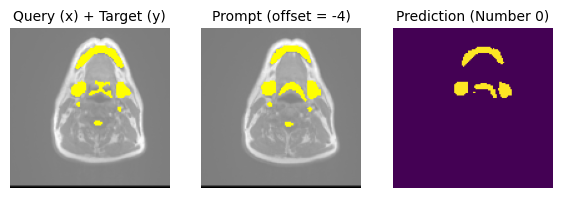

Dice: 0.767



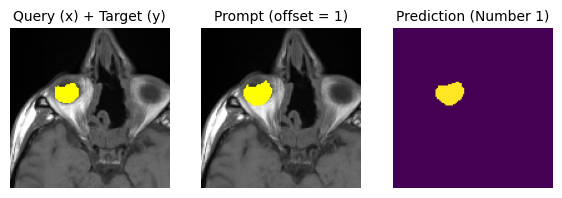

Dice: 0.862



In [2]:
print("--- RUNNING HANSEG (MRI) EVALUATION ---")
dataset_path = ["data/test_data/han_seg_mri.npz"]

# Initialize tester
tester = PromptUNetTester(
    dataset_path=dataset_path,
    models_dir=models_dir,
    max_data_points=max_data_points
)

# Execute full validation loop
results_hanseg = tester.run_pipeline(
    dimensions=dimensions, 
    offsets=offsets, 
    models=models, 
    threshold=0.5, 
    num_visualize=2
)

### 2. Evaluate on HanSeg (CT)

--- RUNNING HANSEG (CT) EVALUATION ---

Loading NPZ dataset(s)…
Loaded 42 PIDs from /home/dpxuser/prompt-unet/data/test_data/han_seg_ct.npz

Final dataset size: 42 patients.


   EVALUATING OFFSET: 5 | AXIS: ['x', 'y', 'z']

Creating new Data Points ...
It took 104 seconds

--- [SECTION 1: METRICS] ---
Testing p_unet_21.keras... Done. Took 236.9 seconds.
[p_unet_21.keras] -> Avg Dice: 0.796
Testing p_unet_292.keras... Done. Took 318.8 seconds.
[p_unet_292.keras] -> Avg Dice: 0.809
Testing p_unet_300.keras... Done. Took 492.9 seconds.
[p_unet_300.keras] -> Avg Dice: 0.801
Testing p_unet_301.keras... Done. Took 481.9 seconds.
[p_unet_301.keras] -> Avg Dice: 0.800

   EVALUATING OFFSET: 12 | AXIS: ['x', 'y', 'z']

Creating new Data Points ...
It took 69 seconds

--- [SECTION 1: METRICS] ---
Testing p_unet_21.keras... Done. Took 235.1 seconds.
[p_unet_21.keras] -> Avg Dice: 0.717
Testing p_unet_292.keras... Done. Took 314.5 seconds.
[p_unet_292.keras] -> Avg Dice: 0.738
Testing p_unet_300.

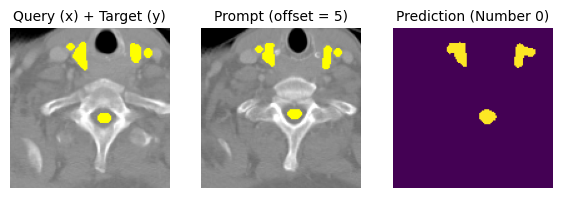

Dice: 0.736



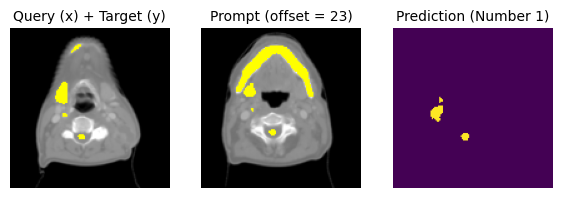

Dice: 0.181


>> Visualizing predictions for: p_unet_292.keras (Threshold: 0.5)


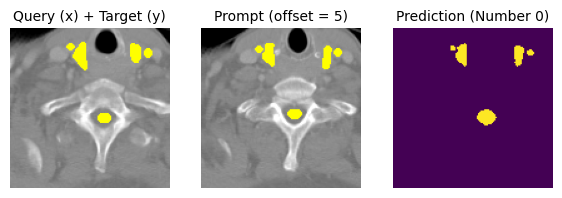

Dice: 0.742



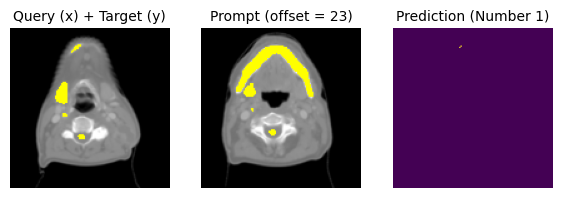

Dice: 0.021


>> Visualizing predictions for: p_unet_300.keras (Threshold: 0.5)


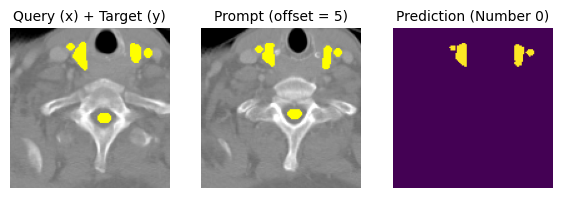

Dice: 0.704



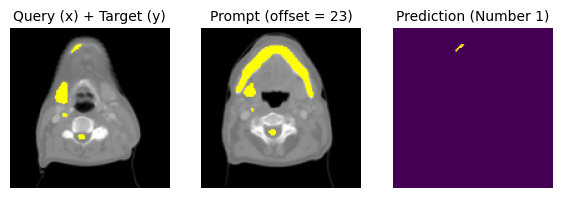

Dice: 0.139


>> Visualizing predictions for: p_unet_301.keras (Threshold: 0.5)


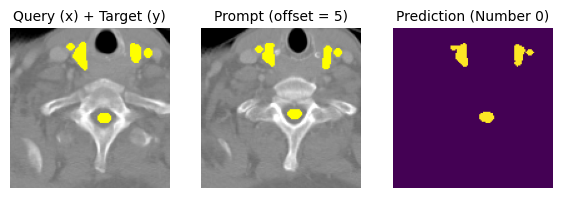

Dice: 0.813



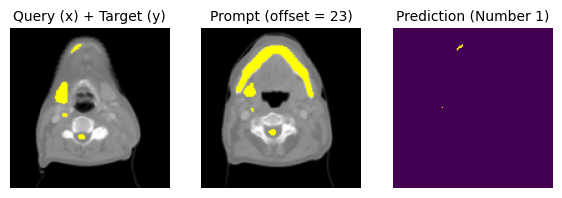

Dice: 0.101



In [2]:
print("--- RUNNING HANSEG (CT) EVALUATION ---")
dataset_path = ["data/test_data/han_seg_ct.npz"]

# Initialize tester
tester = PromptUNetTester(
    dataset_path=dataset_path,
    models_dir=models_dir,
    max_data_points=max_data_points
)

# Execute full validation loop 
results_hanseg = tester.run_pipeline(
    dimensions=dimensions, 
    offsets=offsets, 
    models=models, 
    threshold=0.5, 
    num_visualize=2
)

### 3. Evaluate on FLARE (CT)

--- RUNNING FLARE (CT) EVALUATION ---

Loading NPZ dataset(s)…
Loaded 50 PIDs from /home/dpxuser/prompt-unet/data/test_data/FLARE_2022.npz

Final dataset size: 50 patients.


   EVALUATING OFFSET: 5 | AXIS: ['x', 'y', 'z']

Creating new Data Points ...
It took 26 seconds

--- [SECTION 1: METRICS] ---
Testing p_unet_21.keras... Done. Took 233.2 seconds.
[p_unet_21.keras] -> Avg Dice: 0.928
Testing p_unet_292.keras... Done. Took 307.5 seconds.
[p_unet_292.keras] -> Avg Dice: 0.954
Testing p_unet_300.keras... Done. Took 486.4 seconds.
[p_unet_300.keras] -> Avg Dice: 0.957
Testing p_unet_301.keras... Done. Took 481.9 seconds.
[p_unet_301.keras] -> Avg Dice: 0.955

   EVALUATING OFFSET: 12 | AXIS: ['x', 'y', 'z']

Creating new Data Points ...
It took 30 seconds

--- [SECTION 1: METRICS] ---
Testing p_unet_21.keras... Done. Took 235.3 seconds.
[p_unet_21.keras] -> Avg Dice: 0.873
Testing p_unet_292.keras... Done. Took 335.5 seconds.
[p_unet_292.keras] -> Avg Dice: 0.930
Testing p_unet_300.ke

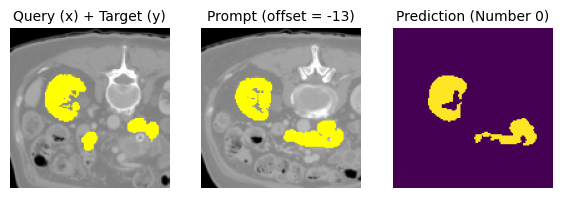

Dice: 0.773



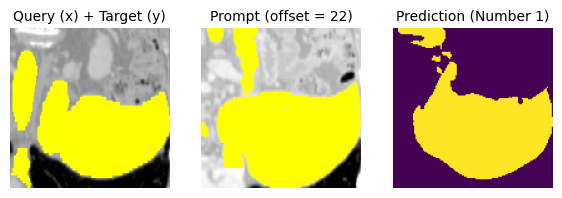

Dice: 0.820


>> Visualizing predictions for: p_unet_292.keras (Threshold: 0.5)


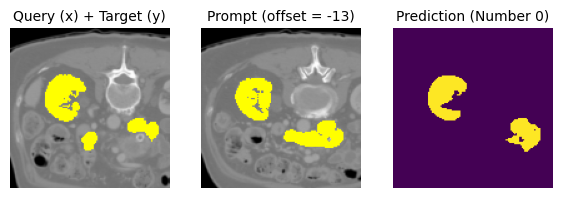

Dice: 0.791



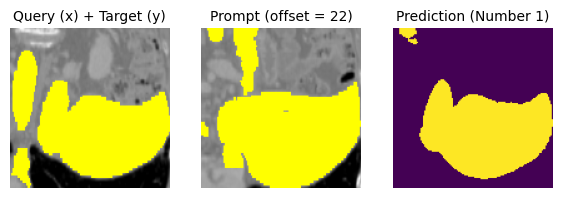

Dice: 0.876


>> Visualizing predictions for: p_unet_300.keras (Threshold: 0.5)


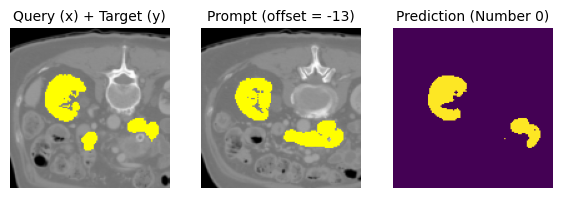

Dice: 0.841



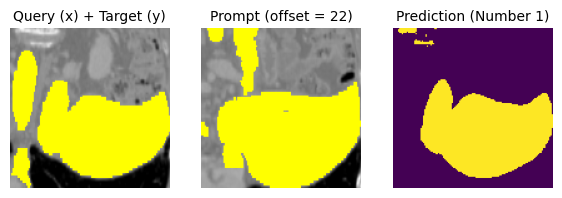

Dice: 0.878


>> Visualizing predictions for: p_unet_301.keras (Threshold: 0.5)


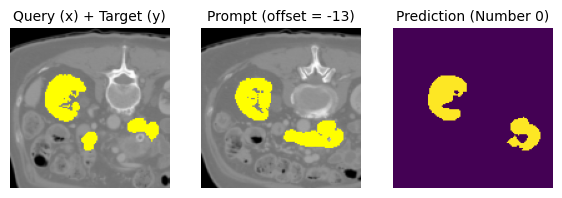

Dice: 0.803



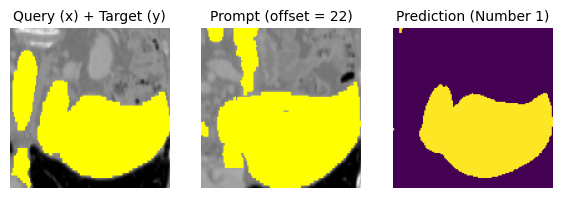

Dice: 0.879



In [3]:
print("--- RUNNING FLARE (CT) EVALUATION ---")
dataset_path = ["data/test_data/FLARE_2022.npz"]

# Initialize tester
tester = PromptUNetTester(
    dataset_path=dataset_path,
    models_dir=models_dir,
    max_data_points=max_data_points
)

# Execute full validation loop
results_flare = tester.run_pipeline(
    dimensions=dimensions, 
    offsets=offsets, 
    models=models, 
    threshold=0.5, 
    num_visualize=2
)